MSE Model
Final Loss: 0.0005726637318730354
Final Accuracy: 100.0 %

BCE Model
Final Loss: 0.004399493336677551
Final Accuracy: 100.0 %

MSE Predictions:
[[0.01349301]
 [0.9667466 ]
 [0.98995304]
 [0.03003107]]

BCE Predictions:
[[0.00194121]
 [0.9991733 ]
 [0.99217224]
 [0.00694508]]


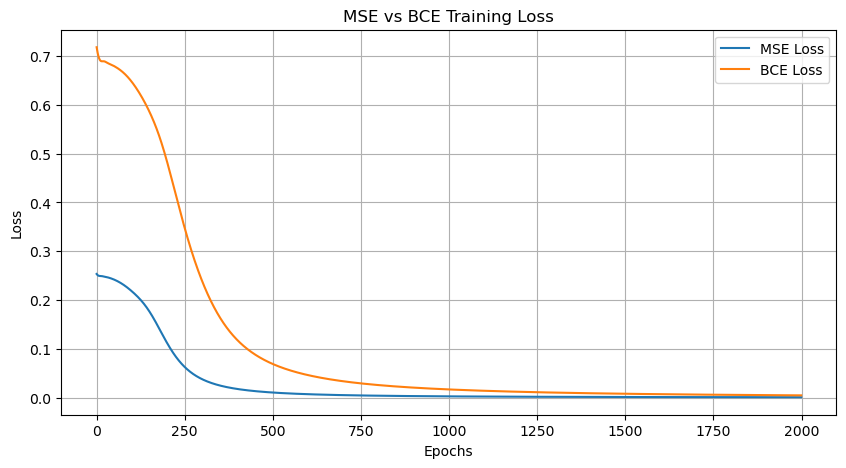

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)


# -----------------------------
# Model A - MSE Loss
# -----------------------------

model_mse = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_mse.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['accuracy']
)


# -----------------------------
# Model B - BCE Loss
# -----------------------------

model_bce = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_bce.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# -----------------------------
# Train both models
# -----------------------------

history_mse = model_mse.fit(
    X, y,
    epochs=2000,
    verbose=0
)

history_bce = model_bce.fit(
    X, y,
    epochs=2000,
    verbose=0
)


# -----------------------------
# Evaluate Models
# -----------------------------

loss_mse, acc_mse = model_mse.evaluate(X, y, verbose=0)
loss_bce, acc_bce = model_bce.evaluate(X, y, verbose=0)

print("MSE Model")
print("Final Loss:", loss_mse)
print("Final Accuracy:", acc_mse * 100, "%")

print("\nBCE Model")
print("Final Loss:", loss_bce)
print("Final Accuracy:", acc_bce * 100, "%")


# -----------------------------
# Predictions
# -----------------------------

pred_mse = model_mse.predict(X, verbose=0)
pred_bce = model_bce.predict(X, verbose=0)

print("\nMSE Predictions:")
print(pred_mse)

print("\nBCE Predictions:")
print(pred_bce)


# -----------------------------
# Plot Training Loss
# -----------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    history_mse.history['loss'],
    label='MSE Loss'
)

plt.plot(
    history_bce.history['loss'],
    label='BCE Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MSE vs BCE Training Loss")
plt.legend()
plt.grid(True)

plt.show()

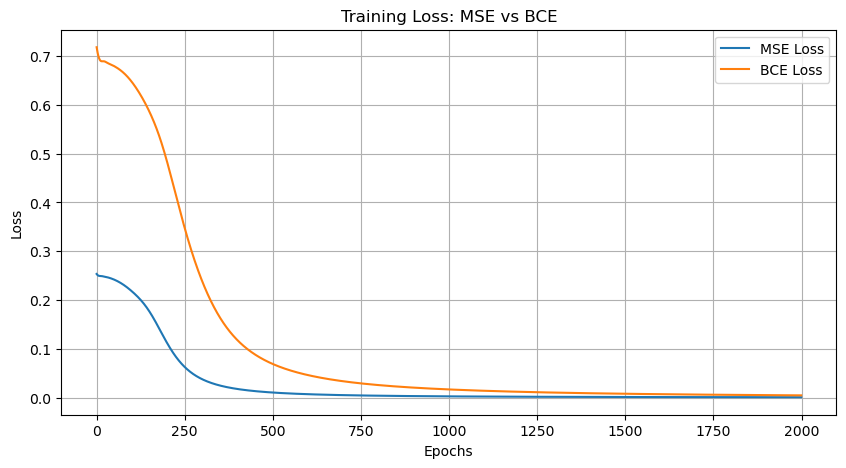

In [7]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_mse.history['loss'],
    label='MSE Loss'
)

plt.plot(
    history_bce.history['loss'],
    label='BCE Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss: MSE vs BCE")
plt.legend()
plt.grid(True)

plt.show()

Predicted probabilities:
[[0.01270694]
 [0.9836999 ]
 [0.9290505 ]
 [0.07453624]]

Predicted classes:
[[0]
 [1]
 [1]
 [0]]

Actual classes:
[[0]
 [1]
 [1]
 [0]]

Final Accuracy: 100.0 %


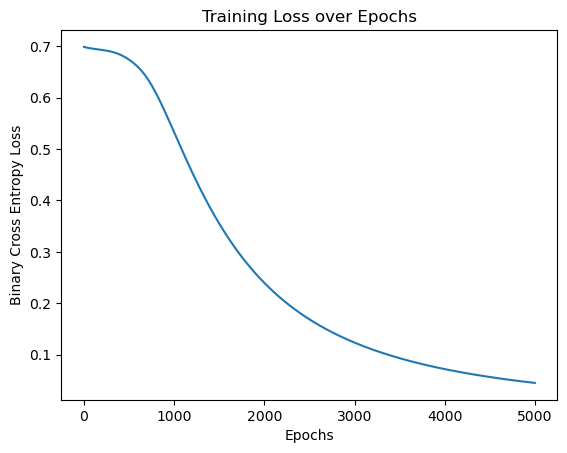

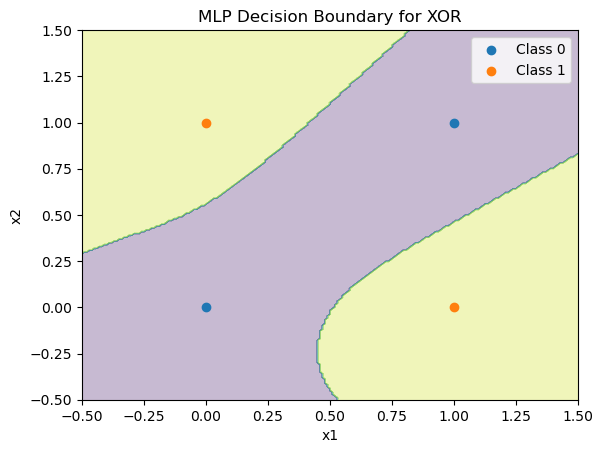

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# XOR input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# XOR output
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

# Create MLP model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation='sigmoid'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X, y,
    epochs=5000,
    verbose=0
)

# Predict
pred_prob = model.predict(X, verbose=0)
pred = (pred_prob >= 0.5).astype(int)

# Calculate accuracy
accuracy = np.mean(pred == y) * 100

print("Predicted probabilities:")
print(pred_prob)

print("\nPredicted classes:")
print(pred)

print("\nActual classes:")
print(y.astype(int))

print("\nFinal Accuracy:", accuracy, "%")

# Plot training loss
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss over Epochs")
plt.show()

# Decision boundary visualization
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = model.predict(grid, verbose=0)
Z = (Z >= 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[y.ravel() == 0, 0],
    X[y.ravel() == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y.ravel() == 1, 0],
    X[y.ravel() == 1, 1],
    label="Class 1"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("MLP Decision Boundary for XOR")
plt.legend()
plt.show()

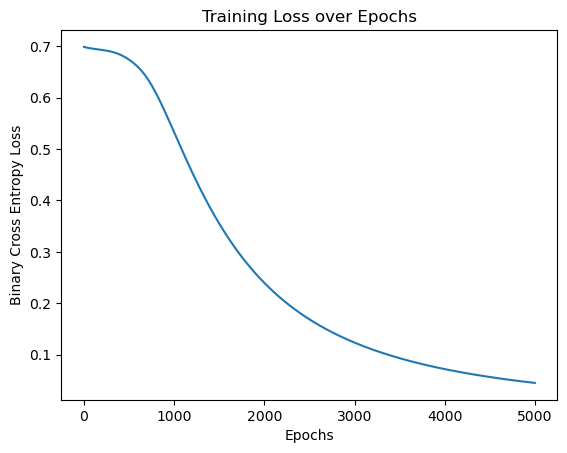

In [15]:
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [16]:
pred_prob = model.predict(X)
pred = (pred_prob >= 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


In [17]:
accuracy = np.mean(pred == y) * 100